<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [30]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
except ImportError:
    # Not running in Colab → do nothing
    pass

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

# Load Data
Labeled Datasets for Research on Information Operations

In [32]:
from pathlib import Path

dataset_name = "Labeled_Datasets"
file_name = "Ecuador/Ecuador_part_3.gzip.parquet"

# Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    in_colab = True
    print("Running inside Colab. Loading from Google Drive...")

# BGU Slurm Cluster
except ImportError:
    # working directory is: Backbone-Graph/src
    file_path = Path("../data") / dataset_name / file_name
    in_colab = False
    print("Running on Slurm cluster. Loading local file...")


# Load the parquet file
df = pd.read_parquet(file_path)

Running on Slurm cluster. Loading local file...


In [33]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
100000,43394c24c54037f763e8318026ffba9aeb9317f672,"Queda prohibido no sonreir a los problemas, no...",2727201c363b6fc4afe259ba4094ae0c49cb4df224,None,None,None,2013-02-21 16:02:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,True,5ff80261b935621244fb38fff05231bf108ba8a488,4af2ce0fdafbc22f1a0be317a2f1025f2b18983194,[],[],[5ff80261b935621244fb38fff05231bf108ba8a488],False
100001,1b6cb8bafe65e8b9e639b7e52075c8ebf34d854d6c,"Te encontraras con gente hipócrita, con amigos...",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-02-21 16:04:04,8949eab1b3f746ed66a069ae5d6c415a57dc546ffc,Agradecida con Dios y con la Vida. Ahora en #...,471,233,2010-08-25,False,None,None,[],[],[],True
100002,4b69e40a8e23031f7ddc3832dfe5f289e851b56299,Aventarle un diccionario a alguien en la cabez...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-02-21 16:04:12,8949eab1b3f746ed66a069ae5d6c415a57dc546ffc,Agradecida con Dios y con la Vida. Ahora en #...,471,233,2010-08-25,False,None,None,[],[],[],True
100003,f810b69a925e539fb18b86ad0d227751cf072738bd,"Suena mi alarma del celu, tendre que levantarm...",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-02-21 16:04:16,8949eab1b3f746ed66a069ae5d6c415a57dc546ffc,Agradecida con Dios y con la Vida. Ahora en #...,471,233,2010-08-25,True,7e6b7dd1aa865b143fc37f4181e392613d1e6dfe3f,e6e93d6dcfdca0ea6ba2104dc6532ade3f85263147,[],[],[7e6b7dd1aa865b143fc37f4181e392613d1e6dfe3f],True
100004,94e00228f2ac99ef8ae06ab1c5419e74dfd7dc4699,En el mar la vida es mas sabrosa 8' @5b3c3e3a2...,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2013-02-21 16:15:00,4a08f9f3e1b73d62e982f899cdfb644e2101bd28a4,Grateful💕,587,270,2010-06-06,True,ad1f5918aa283b31785d589c2ade1c1ca176a23a47,4e9a2c4ec3f5bb6ec24e2936e287ac2fa33b30245d,[],[https://f87702c9a584719155693093bf96b50d218e8...,"[ad1f5918aa283b31785d589c2ade1c1ca176a23a47, 5...",False


## Dataset Statistics

In [34]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts().head())

df shape:                                (50000, 19)
df posts with hashtags # shape:          (22419, 19)  (44.84%)
df posts with account_mentions @ shape:  (31089, 19)  (62.18%)
df posts with urls shape:                (18968, 19)  (37.94%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control          

# Clean Text

In [35]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [36]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [37]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Engllish Stopwords

In [38]:
from nltk.corpus import stopwords
import nltk

In [39]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [41]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
100000,"Queda prohibido no sonreir a los problemas, no...","queda prohibido sonreir los problemas, luchar ..."
100001,"Te encontraras con gente hipócrita, con amigos...","te encontraras con gente hipócrita, con amigos..."
100002,Aventarle un diccionario a alguien en la cabez...,aventarle un diccionario alguien en la cabeza ...
100003,"Suena mi alarma del celu, tendre que levantarm...","suena mi alarma del celu, tendre que levantarm..."
100004,En el mar la vida es mas sabrosa 8' @5b3c3e3a2...,en el mar la vida es mas sabrosa 8' mention_5b...
100005,"—Abue, ¿por qué tienes la boca tan grande? —Tú...","—abue, ¿por qué tienes la boca tan grande? —tú..."
100006,Ver fotos del pasado.. recordar y llorar por e...,ver fotos del pasado.. recordar llorar por esa...
100007,@597739f6dae7bf858889e6e3d126ae99e935ee9415 ja...,mention_597739f6dae7bf858889e6e3d126ae99e935ee...
100008,Tengo mi sonrisa lista para cuando te vea.,tengo mi sonrisa lista para cuando te vea.
100009,"Si quieres saber donde está tu corazón, mira d...","si quieres saber donde está tu corazón, mira d..."


# Topic Clustering

## Utils


In [42]:
def make_topic_stats(df):

  topic_stats = (
      df.groupby("topic")
        .agg(
            Count=("topic", "count"),
            IO_Count=("is_control", lambda x: (~x).sum())   # count where is_control == False
        )
        .reset_index()
        .rename(columns={"topic": "Topic"})
  )
  topic_stats["Legitimate_posts"] = topic_stats["Count"] - topic_stats["IO_Count"]

  return topic_stats

In [43]:
def plot_topic_stats(topic_stats):
    topics = topic_stats["Topic"]
    io_count = topic_stats["IO_Count"]
    legitimate_count = topic_stats["Legitimate_posts"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.title("Post Count per Topic")
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()
    plt.show()

## BERTopic **English** Topic Clustering

In [44]:
# For Testing Only
df = df[df["post_language"] == "en"].copy()
print(f"english_df shape: {df.shape}")

english_df shape: (9504, 20)


In [56]:
def english_BERTopic_modeling(posts_text_lst, min_topic_size=100):

    embedding_model = SentenceTransformer("digio/Twitter4SSE")

    topic_model = BERTopic(
        embedding_model=embedding_model,
        language="english",
        min_topic_size=min_topic_size,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(posts_text_lst)

    return topics, probs, topic_model

In [46]:
posts_text_lst = df["clean_post_text"].to_list()

topics, probs, BERTopic_model = english_BERTopic_modeling(posts_text_lst)

df["topic"] = topics

BERTopic_model.get_topic_info()

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.
2025-11-23 18:36:08,383 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 297/297 [00:08<00:00, 34.19it/s]
2025-11-23 18:36:17,160 - BERTopic - Embedding - Completed ✓
2025-11-23 18:36:17,160 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-23 18:36:38,643 - BERTopic - Dimensionality - Completed ✓
2025-11-23 18:36:38,645 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-23 18:36:38,973 - BERTopic - Cluster - Completed ✓
2025-11-23 18:36:38,977 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-23 18:36:39,202 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2572,-1_emoji_red_heart_emoji_fish_love_shit,"[emoji_red_heart, emoji_fish, love, shit, me, ...","[sex boy mom ! "" url_79b18d738883c8b85735ca193..."
1,0,785,0_lol_mention_0e11eceb7a209e74eb5e6c60f342a3ae...,"[lol, mention_0e11eceb7a209e74eb5e6c60f342a3ae...",[mention_2180630b56ebb326f62ae1400236ab454812f...
2,1,191,1_emoji_face_with_tears_of_joy_emoji_weary_fac...,"[emoji_face_with_tears_of_joy, emoji_weary_fac...",[nephew coming emoji_face_with_tears_of_joy em...
3,2,145,2_hashtag_adidas_adidas_hashtag_pro_hashtag_cl...,"[hashtag_adidas, adidas, hashtag_pro, hashtag_...",[hashtag_adidas celebrates... hashtag_barcelon...
4,3,133,3_hashtag_win_enter_win_chance,"[hashtag_win, enter, win, chance, hashtag_comp...",[hashtag_win hashtag_hugbox reach 3000 followe...
...,...,...,...,...,...
193,192,11,192_hashtag_esmeraldas_26_nublado_21,"[hashtag_esmeraldas, 26, nublado, 21, km, hr, ...",[hashtag_esmeraldas current conditions: (as 06...
194,193,10,193_77738338a508734abe24c3bbb1b7c164de3a66774e...,"[77738338a508734abe24c3bbb1b7c164de3a66774e, e...",[girls' generation header. hashtag_1 || 777383...
195,194,10,194_school_hashtag_inmiddleschool_high_url_009...,"[school, hashtag_inmiddleschool, high, url_009...",[hashtag_realesttweet “ mention_9e1f4db2985b4f...
196,195,10,195_witchcraft_bleak_situation_emergency,"[witchcraft, bleak, situation, emergency, call...",[nebraska follow me@ realdatill fukushima \'em...


BERTopic


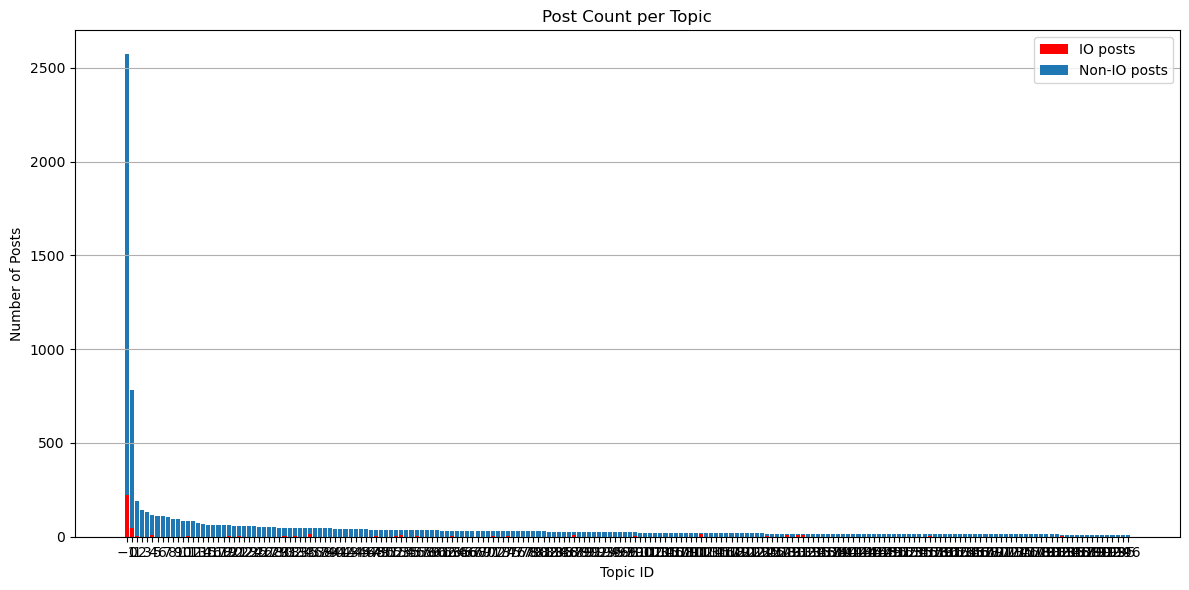

In [47]:
print("BERTopic")
topic_stats = make_topic_stats(df)
plot_topic_stats(topic_stats)

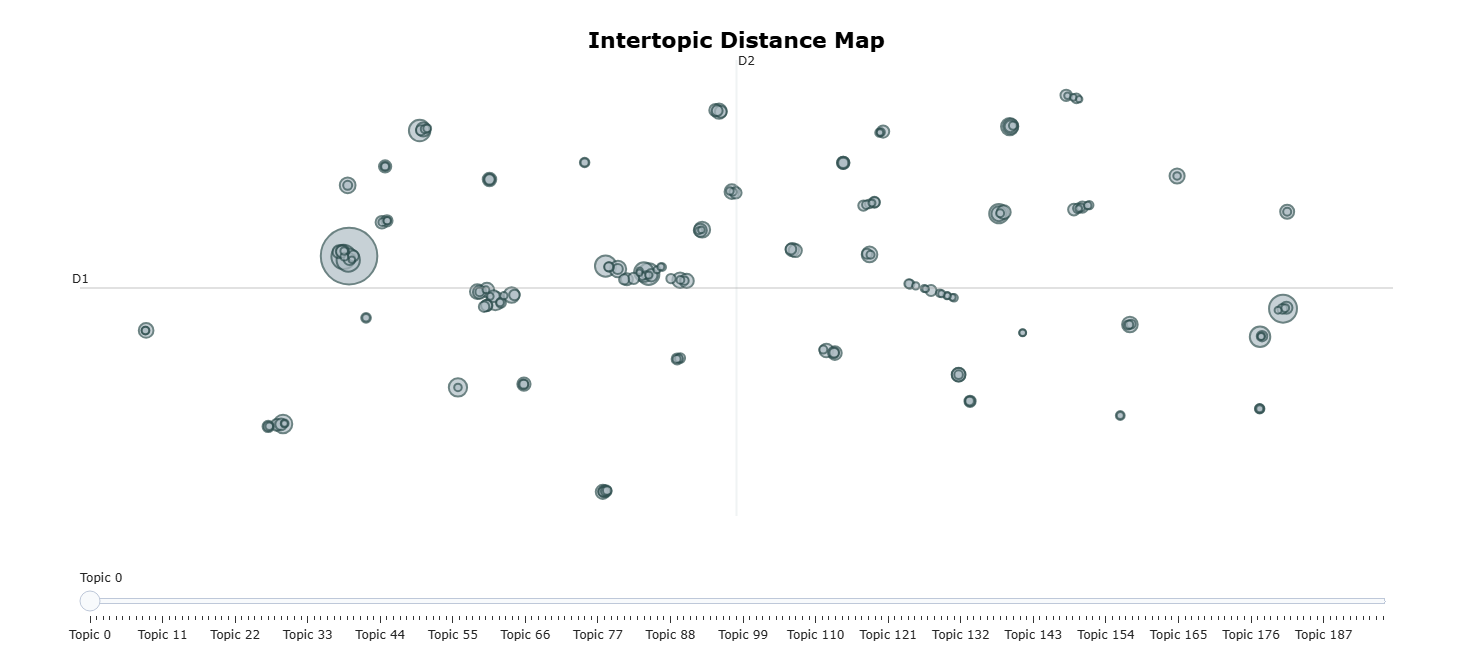

In [48]:
BERTopic_model.visualize_topics(custom_labels=True)

In [49]:
## K-Means Topic Clustering (English)

In [50]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

posts_text_lst = df["clean_post_text"].astype(str).to_list()

# Load Twitter-trained model
model = SentenceTransformer("digio/Twitter4SSE")   # trained on tweets

# Emmbeding
embeddings = model.encode(posts_text_lst, show_progress_bar=True)

# Normalize
embeddings = normalize(embeddings)

# Run KMeans clustering

k = 20 # Think how to choose the right number

kmeans_model = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans_model.fit_predict(embeddings)

# Add to df
df["Kmeans_topic"] = labels

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.
Batches: 100%|██████████| 297/297 [00:08<00:00, 34.48it/s]


In [51]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control,clean_post_text,topic,Kmeans_topic
100031,65fae3379194b163422c45103e0bd75865718b4c70,@72c233209dc9fa95258de4150952791cc619e258cc ch...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,None,None,2013-02-21 17:31:45,456764acce17efc2a9808048b562562b6fc58b3cba,i wanna tell you not to get lost in these pett...,2542,...,True,68f34643e8134fb7830cb298c3e679f42f6db64259,c4defc4266e65b38a842c43f8c08ff4d89ea2d3ebe,[],[],"[68f34643e8134fb7830cb298c3e679f42f6db64259, 7...",True,mention_72c233209dc9fa95258de4150952791cc619e2...,0,11
100032,a21753411d9767b1706319fe1615e76d96da6406e3,White Stripes! https://e41b04e5a81c5f08e7ff672...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,None,None,2013-02-21 17:43:17,456764acce17efc2a9808048b562562b6fc58b3cba,i wanna tell you not to get lost in these pett...,2542,...,False,None,None,[],[https://e41b04e5a81c5f08e7ff672325c6bcbb7d081...,[],True,white stripes! url_e41b04e5a81c5f08e7ff672325c...,-1,10
100148,a83847d936874fe1e35d4c913f1e19680e10cea434,To keep me just...,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,en,None,None,2013-02-22 03:56:35,5ba3e34bab4e9b10a56049a5db5633442670caa01a,tão longe que ninguém alcança,350,...,False,None,None,[],[],[],True,keep just...,-1,19
100187,60b507e63fc5a01165610d45cfaac99d6fa8ac66c2,Lost and insecure you found me..,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,en,None,None,2013-02-22 05:35:31,5ba3e34bab4e9b10a56049a5db5633442670caa01a,tão longe que ninguém alcança,350,...,False,None,None,[],[],[],True,lost insecure found me..,-1,15
100191,3ef7016d382a1c1b1c3a5d7eccf933d18b9d1aa3b6,we're beautiful like diamonds in the sky,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,None,None,2013-02-22 06:05:32,d73888fbd34ee934eb2d2d4a28b26cfd1426178ab8,Dimas Aji Saputra A.k.a DRONE🚀 | db7b78e67f038...,291,...,False,None,None,[],[],[],True,beautiful diamonds sky,132,16


# Named Entity Recognition (NER)

In [52]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [53]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [54]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
100239,mention_6718298b85826dfa74019b2e1c40a2dda04dc1...,"[mc@@, don@@, ald@@]"
100240,mention_f82a72e78fbfe0c50f93a4f39249328c6186bf...,[burger king]
100248,emoji_tired_face mention_835b81473c2c443e78d30...,[rihanna]
100249,pic rihanna horrible. less ass,[rihanna]
100300,come scoop young thug !!!,[young thug]


# Save to parquet

In [55]:
# from pathlib import Path

file_path = Path(file_path)


if in_colab:
  output_path = (file_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / file_path.parent.name / file_path.name)
else:
  # working directory is: Backbone-Graph/src
  output_path = Path("../results") / dataset_name / "Topic_NER" / file_name

output_path.parent.mkdir(parents=True, exist_ok=True) # Creates the parent directory if needed

df.to_parquet(output_path, index=False, compression="gzip")

print(output_path)

../results/Labeled_Datasets/Topic_NER/Ecuador/Ecuador_part_3.gzip.parquet
